# Overtime early warning — what the data supports

It is **Wednesday 12 August 2026**. The week Mon 10 → Sun 16 Aug is three days old, and payroll
will not reveal who breached until Monday, when the cost is already accrued.

> **Who will breach the 10-hour overtime cap by Sunday?**

Five findings, in the order that they constrain what can be built.

In [21]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from src.db import connect

plt.rcParams.update({"figure.figsize": (11,3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 80)

conn = connect(Path.cwd().parent / "shifts.db")
shifts   = pd.read_sql("SELECT * FROM shifts", conn, parse_dates=["shift_date","start_at","end_at"])
notes    = pd.read_sql("SELECT * FROM shift_notes", conn)
holidays = pd.read_sql("SELECT * FROM public_holidays", conn, parse_dates=["date"])
client   = pd.read_sql("SELECT * FROM weekly_summary", conn, parse_dates=["week_starting"])
window   = pd.read_sql("SELECT * FROM v_data_range", conn).iloc[0]
CURRENT  = pd.Timestamp(window.current_week_start)

shifts["hours"] = (shifts.end_at - shifts.start_at).dt.total_seconds()/3600
shifts["week"]  = shifts.shift_date - pd.to_timedelta(shifts.shift_date.dt.weekday, unit="D")
shifts["dow"]   = shifts.shift_date.dt.weekday

day = (shifts.pivot_table(index=["employee_id","week"], columns="dow", values="hours", aggfunc="sum")
             .reindex(columns=range(7)).fillna(0.0))
day.columns = ["mon","tue","wed","thu","fri","sat","sun"]
w = day.reset_index()
w["total"]   = day.sum(axis=1).values
w["mon_wed"] = day[["mon","tue","wed"]].sum(axis=1).values
w["thu_sun"] = day[["thu","fri","sat","sun"]].sum(axis=1).values
w["breached"] = (w.total > 55).astype(int)
done, live = w[w.week < CURRENT], w[w.week == CURRENT]

print(f"{len(shifts):,} shifts | {shifts.employee_id.nunique()} employees | "
      f"{window.min_shift_date} to {window.max_shift_date} ({pd.Timestamp(window.max_shift_date):%A})")
print(f"reporting week {window.current_week_start} to {window.current_week_end}")

8,863 shifts | 213 employees | 2026-06-08 to 2026-08-12 (Wednesday)
reporting week 2026-08-10 to 2026-08-16


## 1. The target is deterministic — a breach is a week over 55 hours

In [22]:
ours = shifts.groupby(["employee_id","week"], as_index=False).hours.sum()
check = client.merge(ours, left_on=["employee_id","week_starting"],
                     right_on=["employee_id","week"], how="inner")
print(f"employee-weeks reconciled against the client's own roll-up: {len(check):,}")
print(f"rows where our hours differ:                                {(check.total_hours - check.hours).abs().gt(0.001).sum()}")
print(f"overtime_hours == max(total - 45, 0):  {np.allclose(check.overtime_hours, (check.total_hours-45).clip(lower=0))}")
print(f"breached       == (overtime > 10):     {(check.breached == (check.overtime_hours > 10)).all()}")

employee-weeks reconciled against the client's own roll-up: 2,122
rows where our hours differ:                                0
overtime_hours == max(total - 45, 0):  True
breached       == (overtime > 10):     True


Our recomputed hours match the client's export on **every row**, so we can read their rule
straight off the file: **breach ⟺ week total > 55 hours**. Sunday and public-holiday work is paid
at 2x, but multipliers never enter the cap — they affect cost, not compliance.

This matters for framing. Monday to Wednesday is already known exactly. The only unknown is
Thursday to Sunday, so predicting a breach means forecasting one number and asking whether it
clears the remaining budget.

## 2. The event is rare, and it does not stick to people

In [23]:
panel = done.pivot(index="employee_id", columns="week", values="breached")
lag = np.corrcoef(panel.values[:,1:].ravel(), panel.values[:,:-1].ravel())[0,1]
print(f"completed employee-weeks   {len(done):,}")
print(f"breaches                   {done.breached.sum()}  (base rate {done.breached.mean():.2%})")
print(f"employees who ever breached {int((panel.sum(axis=1)>0).sum())} of {len(panel)}")
print(f"\nweeks breached, per employee:\n{panel.sum(axis=1).value_counts().sort_index().to_string()}")
print(f"\ncorrelation between breaching this week and last: {lag:.3f}")

completed employee-weeks   1,917
breaches                   66  (base rate 3.44%)
employees who ever breached 49 of 213

weeks breached, per employee:
0    164
1     39
2      4
3      5
4      1

correlation between breaching this week and last: 0.050


A 3.4% base rate means predicting "nobody breaches" is right 96.6% of the time, so accuracy is a
useless metric here.

More importantly, breaching is **not a property of particular people**. 49 employees breached at
least once; almost all did it exactly once and never again, and the week-to-week correlation is
0.05. So *"who breached last week"* — the most obvious baseline available — is worth essentially
nothing. Overtime here is driven by what is happening on site this week, not by habitual
over-workers.

## 3. The core finding: the week compensates against itself

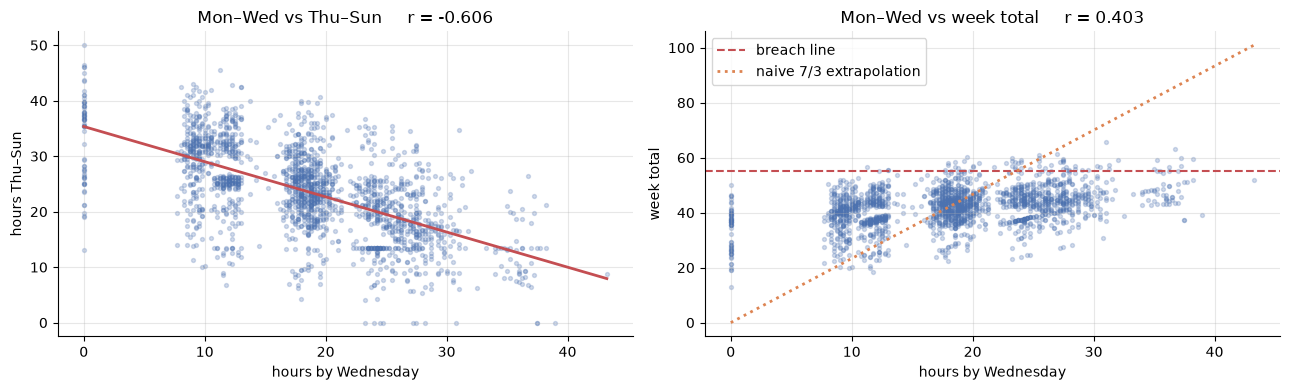

breachers     — Mon–Wed  25.8h, Thu–Sun  31.8h
non-breachers — Mon–Wed  18.1h, Thu–Sun  23.4h


In [24]:
r = done.mon_wed.corr(done.thu_sun)
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].scatter(done.mon_wed, done.thu_sun, s=8, alpha=.25, color="#4C72B0")
xs = np.linspace(0, done.mon_wed.max(), 50)
ax[0].plot(xs, np.polyval(np.polyfit(done.mon_wed, done.thu_sun, 1), xs), color="#C44E52", lw=2)
ax[0].set(title=f"Mon–Wed vs Thu–Sun     r = {r:.3f}", xlabel="hours by Wednesday", ylabel="hours Thu–Sun")

ax[1].scatter(done.mon_wed, done.total, s=8, alpha=.25, color="#4C72B0")
ax[1].axhline(55, color="#C44E52", ls="--", label="breach line")
ax[1].plot(xs, xs*7/3, color="#DD8452", ls=":", lw=2, label="naive 7/3 extrapolation")
ax[1].set(title=f"Mon–Wed vs week total     r = {done.mon_wed.corr(done.total):.3f}",
          xlabel="hours by Wednesday", ylabel="week total"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"breachers     — Mon–Wed {done[done.breached==1].mon_wed.mean():5.1f}h, Thu–Sun {done[done.breached==1].thu_sun.mean():5.1f}h")
print(f"non-breachers — Mon–Wed {done[done.breached==0].mon_wed.mean():5.1f}h, Thu–Sun {done[done.breached==0].thu_sun.mean():5.1f}h")

**Hours worked Monday to Wednesday correlate −0.61 with hours worked Thursday to Sunday.** A heavy
start buys a light weekend; the roster compensates.

This kills the intuitive approach. The dotted line is what "scale up the current pace" predicts,
and it sits far above the real relationship — it would flag a large fraction of the workforce.

It also shows why the problem is hard rather than merely rare. Breachers are only ~8 hours ahead
by Wednesday, but a further ~8 hours ahead over the weekend. **Most of a breach happens after the
data stops.**

## 4. How much signal is actually there

In [25]:
# How well can Thursday-to-Sunday hours be predicted at all?
h = done.sort_values(["employee_id","week"]).copy()
g = h.groupby("employee_id")
h["prior_total"] = g.total.transform(lambda s: s.shift(1).expanding().mean())
h["mw_days"] = (h[["mon","tue","wed"]] > 0).sum(axis=1)
h["ts_days"] = (h[["thu","fri","sat","sun"]] > 0).sum(axis=1)
d = h.dropna(subset=["prior_total"])

def r2(cols, target):
    M = np.column_stack([np.ones(len(d))] + [d[c].to_numpy(float) for c in cols])
    beta, *_ = np.linalg.lstsq(M, d[target].to_numpy(float), rcond=None)
    resid = d[target].to_numpy(float) - M @ beta
    return 1 - (resid**2).sum() / ((d[target] - d[target].mean())**2).sum()

print(f"R2 predicting Thu–Sun hours from...")
print(f"   hours by Wednesday                       {r2(['mon_wed'],'thu_sun'):.3f}")
print(f"   + days worked                            {r2(['mon_wed','mw_days'],'thu_sun'):.3f}")
print(f"   + the employee's own average week        {r2(['mon_wed','mw_days','prior_total'],'thu_sun'):.3f}")
print(f"\nBut Thu–Sun hours are mostly just days worked:")
print(f"   R2 of Thu–Sun hours from days alone      {r2(['ts_days'],'thu_sun'):.3f}")
print(f"   R2 predicting those days from features   {r2(['mon_wed','mw_days','prior_total'],'ts_days'):.3f}   <- the bottleneck")
worked = d[d.ts_days > 0]; hpd = worked.thu_sun / worked.ts_days
print(f"\n   hours per worked day: mean {hpd.mean():.2f}h, sd {hpd.std():.2f}h — nearly constant")
print(f"\nvariance share of Thu–Sun hours between sites: "
      f"{d.assign(s=d.employee_id.map(shifts.groupby('employee_id').site_id.agg(lambda x:x.mode()[0]))).groupby('s').thu_sun.mean().var()/d.thu_sun.var():.4f}")
print(f"variance share between weeks:                   {d.groupby('week').thu_sun.mean().var()/d.thu_sun.var():.4f}")

R2 predicting Thu–Sun hours from...
   hours by Wednesday                       0.363
   + days worked                            0.366
   + the employee's own average week        0.508

But Thu–Sun hours are mostly just days worked:
   R2 of Thu–Sun hours from days alone      0.788
   R2 predicting those days from features   0.399   <- the bottleneck

   hours per worked day: mean 10.00h, sd 1.76h — nearly constant

variance share of Thu–Sun hours between sites: 0.0064
variance share between weeks:                   0.0044


**This is the honest limit of the exercise.** Thursday-to-Sunday hours can be explained to about
R² = 0.51, and no further — adding more history features moves it by thousandths.

The reason is structural. Remaining hours are almost entirely *how many more days they work*
(R² = 0.79), because hours-per-day barely varies (10.0h, sd 1.8). And days-worked is only 40%
predictable. The rest is roster randomness that has not happened yet.

There is also nothing for a sophisticated model to exploit: site explains 0.6% of the variance
and week 0.4%. No interaction structure, no clusters, no regime.

**So any model will struggle, and they will all struggle to about the same degree.** The useful
question is not which algorithm, but how to make a genuinely weak signal actionable — a ranked
shortlist with an honest probability attached, rather than a confident-looking classification.

## 5. This week is not a normal week

In [26]:
print(f"average hours by Wednesday, completed weeks: {done.mon_wed.mean():5.2f}h")
print(f"average hours by Wednesday, this week:       {live.mon_wed.mean():5.2f}h   "
      f"({live.mon_wed.mean()-done.mon_wed.mean():+.2f}h)")
print(f"\nnobody has breached yet — most hours worked Mon–Wed this week: {live.mon_wed.max():.2f}h")
print(f"and nobody ever has by Wednesday: {int((done.mon_wed > 55).sum())} of {len(done):,} completed weeks "
      f"(all-time record Mon–Wed is {done.mon_wed.max():.2f}h)")
print(f"\nshifts so far this week:")
this = shifts[shifts.week == CURRENT]
print(this.groupby(this.shift_date.dt.strftime("%a %d %b")).agg(shifts=("shift_id","size"), hours=("hours","sum")).to_string())
print(f"\n{holidays.assign(day=holidays.date.dt.day_name()).to_string(index=False)}")

average hours by Wednesday, completed weeks: 18.32h
average hours by Wednesday, this week:       20.40h   (+2.08h)

nobody has breached yet — most hours worked Mon–Wed this week: 40.00h
and nobody ever has by Wednesday: 0 of 1,917 completed weeks (all-time record Mon–Wed is 43.25h)

shifts so far this week:
            shifts    hours
shift_date                 
Mon 10 Aug     147  1459.75
Tue 11 Aug     141  1381.75
Wed 12 Aug     142  1381.50

      date                            name     day
2026-06-16                       Youth Day Tuesday
2026-08-10 National Women's Day (observed)  Monday


Two things follow.

**Nobody has already breached — and nobody ever has by a Wednesday**, in any of 1,917 completed
employee-weeks. 55 hours over three days would mean 18.3h a day, and the longest shift in the
data is 13.5h. So every row of the prediction is a genuine forecast; there is no "already over"
group to separate out.

**Monday 10 August was National Women's Day and it was the busiest day of the week** — 147 people
worked it. Those hours are paid at 2x *and* count fully toward the caps, so this week everyone is
carrying expensive hours and sitting closer to the line than a normal Wednesday would suggest.

## 6. The supervisors' notes are templates, not free text

In [27]:
notes["text"] = notes.note.fillna("").str.strip()
distinct = notes.text.str.lower().value_counts()
print(f"{len(notes):,} notes, {len(distinct)} distinct — top 60 cover {distinct.head(60).sum()/len(notes):.0%}\n")
print(distinct.head(10).to_string())

print("\nwhat varies between them:")
for label, pat in [("Afrikaans",       r"stukkend|oorhandiging|gedek vir|klient|masjien|aflos|niks om te"),
                   ("isiZulu",         r"akafikanga|akezanga|ngicela|akukho lutho|ngimele|ngihlale"),
                   ("abbrev / typos",  r"\bagn\b|\bhrs\b|\bmgr\b|conntrol|clint|cnetre|okd'")]:
    hit = notes[notes.text.str.lower().str.contains(pat, regex=True, na=False)]
    print(f"  {label:16s} {len(hit):4d}   e.g. {hit.text.iloc[0]!r}")

2,117 notes, 846 distinct — top 60 cover 50%

text
quiet shift                                                    32
ntr                                                            32
ok                                                             31
requested by centre management for load in, signed off         31
fine                                                           30
sharp                                                          29
n/a                                                            29
client requested deep clean before the audit - approved        27
late handover, waiting on paperwork                            27
client wanted extra man on the gate for the event, approved    27

what varies between them:
  Afrikaans         151   e.g. 'masjien is stukkend, alles met die hand gedoen'
  isiZulu           125   e.g. 'no replacement sent, ngicela sort this out'
  abbrev / typos    125   e.g. 'client signed for the extra hrs but real reason is relief no show again'


In [28]:
OPS = r"relief|did not pitch|no show|nobody came|no replacement|aflos|akafikanga|next shift|covering|stood in for|didnt come in|absent|booked off sick|siek gemeld|gedek vir|akezanga|double duty|2 posts|handover|oorhandiging|ob book|machine|masjien|scrubber|buffer|generator|lift|gate motor|broke|kaput|stukkend|out of order|fault"
CLI = r"client (?:request|ask|want|signed|says)|centre m(?:anage|gr|gmt)|klient|approved|signed off|extra patrol per"
low = notes.text.str.lower().str.replace(r"[.!]+$","",regex=True)
tagged = shifts.merge(notes.assign(ops=low.str.contains(OPS), cli=low.str.contains(CLI))[["shift_id","ops","cli","text"]],
                      on="shift_id", how="left")
kind = np.where(tagged.text.isna(), "no note",
        np.where(tagged.ops & tagged.cli, "both keywords",
        np.where(tagged.ops, "operational failure",
        np.where(tagged.cli, "client requested", "note, neither"))))
summary = tagged.assign(kind=kind).groupby("kind").hours.agg(["size","mean"]).round(2)
summary["excess_vs_9h"] = ((summary["mean"] - 9) * summary["size"]).round(0)
print(summary.sort_values("mean").to_string())

                     size   mean  excess_vs_9h
kind                                          
no note              6746   9.35        2361.0
note, neither         608  10.45         882.0
client requested      420  11.32         974.0
operational failure  1071  11.45        2624.0
both keywords          18  12.21          58.0


846 distinct strings over ~20 underlying templates, permuted by surname, five spellings of 6am,
abbreviations, typos and code-switching into Afrikaans and isiZulu. **That is the argument against
reaching for a language model**: the vocabulary is small and closed, so character n-grams absorb
`conntrol` and `cnetre` for free and a hand-built lexicon covers `stukkend` and `akafikanga` in a
line each — deterministic, auditable, instant, and free.

The notes also carry the *why*. Shifts tagged as operational failure run 11.5h against 9.4h for
un-noted shifts, and account for roughly **2.7× the excess hours** that client-requested work does.
That is the split the contract manager can actually act on.

One warning for the classifier: a handful of notes read *"client signed for the extra hrs but real
reason is relief no show again"*. Every client keyword fires while the supervisor explicitly records
an operational cause. A first-match rule files these as billable and the failure disappears.

## Where this leaves the build

| Settled | |
|---|---|
| Target | week total > 55h; reconciles with the client's export on all 2,122 rows |
| Reporting week | derived from the data, so next Monday's export needs no code change |
| Notes | ~20 templates, three languages — a deterministic classifier, not an LLM |

**The constraint is information, not algorithm.** Thu–Sun hours cap out around R² = 0.51, the
bottleneck is a roster that has not been set yet, and there is no site or week structure for a
richer model to find. Every model family will land in the same place.

So the output should be a **ranked shortlist with a calibrated probability**, not a confident
classification — and the effort belongs in what the manager does with that list, and in the note
taxonomy that explains *why* the hours happened.

Known weaknesses carried forward: 184 shifts never clocked out and count as zero hours (matching
the client's engine), and 126 employee-days have one person clocked in at two sites at overlapping
times — capture errors that the client's roll-up counts, so we count them too and flag them
separately.